# 06. Overlap and Trimming

In the previous notebook, we treated balance diagnostics as a design gate. This notebook studies another design gate that is just as important: **overlap**.

Overlap asks whether the observed data contain comparable treated and untreated units for the covariate profiles where we want to make causal claims. In industry work, overlap problems are common because teams do not assign treatments randomly. They target retention campaigns to high-risk accounts, premium support to strategic customers, discounts to price-sensitive prospects, and fraud interventions to suspicious transactions. That targeting is often the business logic we want to learn from, but it also creates regions where one treatment condition is barely observed.

The core theme of this lecture is simple:

> If the data do not contain both treated and untreated units in a region of the covariate space, no adjustment method can manufacture a credible comparison there.

Trimming, overlap weighting, ATT targeting, and related approaches are not just technical fixes. They usually change the target population. A professional causal analysis should say that out loud.

## Learning Goals

By the end of this notebook, you should be able to:

1. Define positivity, common support, and practical overlap in propensity-score language.
2. Diagnose overlap problems using propensity-score distributions, score-bin support tables, and weight diagnostics.
3. Explain why extreme inverse probability weights are often a symptom of weak overlap.
4. Compare the full-population ATE, trimmed ATE, ATT, and overlap-weighted target estimands.
5. Show, with code, that trimming can improve stability while changing the population being described.
6. Write an industry-facing overlap report that is honest about where the data support causal claims.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.special import expit
from sklearn.metrics import roc_auc_score
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.2")
    dot.attr("graph", labelloc="t", fontsize="18", fontname="DejaVu Sans")
    if title:
        dot.attr(label=title)
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="DejaVu Sans",
        fontsize="11",
        margin="0.12,0.08",
        color="#334155",
    )
    dot.attr("edge", color="#475569", arrowsize="0.8", fontname="DejaVu Sans", fontsize="10")
    for node in sorted(set([u for u, _ in edges] + [v for _, v in edges])):
        dot.node(node, fillcolor=node_colors.get(node, "#f8fafc"))
    for u, v in edges:
        dot.edge(u, v)
    return dot


def clip_prob(p, eps=1e-4):
    """
    Clip probabilities away from zero and one for stable causal weighting.
    
    Idea:
        Propensity scores at the boundaries create explosive inverse-probability weights, so clipping is used here as a numerical safeguard and diagnostic device.
    
    Args:
        p: Probability or propensity-score vector to stabilize before weighting.
        eps: Minimum distance from zero and one used when clipping probabilities.
    
    Returns:
        numpy.ndarray: Probability vector bounded between eps and one minus eps.
    """
    return np.clip(np.asarray(p, dtype=float), eps, 1 - eps)


def weighted_mean_and_var(x, w):
    """Compute a weighted mean and variance for balance diagnostics.

    Args:
        x: Numeric vector or covariate values used in the calculation.
        w: Weight vector used for weighted summaries.

    Returns:
        tuple: Weighted mean and weighted variance.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mean = np.sum(w * x) / np.sum(w)
    var = np.sum(w * (x - mean) ** 2) / np.sum(w)
    return mean, var


def weighted_mean(x, w):
    """Compute a weighted average while handling the lecture’s vector format.

    Args:
        x: Numeric vector or covariate values used in the calculation.
        w: Weight vector used for weighted summaries.

    Returns:
        float: Weighted average.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    return np.sum(w * x) / np.sum(w)


def weighted_difference(frame, outcome="outcome", treatment="treated", weights=None):
    """Compute a weighted treated-minus-control outcome difference.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        outcome: Outcome variable name or vector being analyzed.
        treatment: Treatment indicator or treatment column name.
        weights: Observation weights used to define the target pseudo-population or summary.

    Returns:
        float: Weighted treated-minus-control difference.
    """
    if weights is None:
        weights = np.ones(len(frame))
    weights = np.asarray(weights, dtype=float)
    treated = frame[treatment].to_numpy() == 1
    y = frame[outcome].to_numpy(dtype=float)
    return weighted_mean(y[treated], weights[treated]) - weighted_mean(y[~treated], weights[~treated])


def effective_sample_size(weights):
    """Compute Kish effective sample size from a vector of weights.

    Args:
        weights: Observation weights used to define the target pseudo-population or summary.

    Returns:
        float: Effective sample size implied by the design or weights.
    """
    weights = np.asarray(weights, dtype=float)
    return (weights.sum() ** 2) / np.sum(weights ** 2)


def standardized_mean_differences(frame, covariates, treatment="treated", weights=None):
    """
    Compute standardized mean differences for pre-treatment covariates.
    
    Idea:
        SMDs put covariate imbalance on a common scale so diagnostics can be compared before and after adjustment or weighting.
    
    Args:
        frame: Analysis DataFrame containing the treatment, outcome, score, or covariate columns used by the helper.
        covariates: Pre-treatment covariate columns evaluated for balance or adjustment.
        treatment: Treatment column or treatment value used to define the causal contrast.
        weights: Optional observation weights defining the adjusted pseudo-population.
    
    Returns:
        pandas.DataFrame: Balance diagnostics for each covariate, including treated and comparison summaries.
    """
    if weights is None:
        weights = np.ones(len(frame))
    weights = np.asarray(weights, dtype=float)
    treated = frame[treatment].to_numpy() == 1
    rows = []
    for col in covariates:
        x = frame[col].to_numpy(dtype=float)
        mt, vt = weighted_mean_and_var(x[treated], weights[treated])
        mc, vc = weighted_mean_and_var(x[~treated], weights[~treated])
        pooled_sd = np.sqrt((vt + vc) / 2)
        smd = np.nan if pooled_sd == 0 else (mt - mc) / pooled_sd
        rows.append({
            "covariate": col,
            "treated_mean": mt,
            "control_mean": mc,
            "smd": smd,
            "abs_smd": abs(smd),
        })
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


def balance_dashboard(balance_table, weights=None, threshold=0.10):
    """Summarize balance quality, maximum imbalance, and effective sample size for a design.

    Args:
        balance_table: Covariate-balance table used for diagnostics.
        weights: Observation weights used to define the target pseudo-population or summary.
        threshold: Diagnostic threshold used to flag imbalance.

    Returns:
        pandas.Series: Balance summary for a candidate design.
    """
    row = {
        "max_abs_smd": balance_table["abs_smd"].max(),
        "mean_abs_smd": balance_table["abs_smd"].mean(),
        "covariates_above_0.10": int((balance_table["abs_smd"] > threshold).sum()),
    }
    if weights is not None:
        row["ess"] = effective_sample_size(weights)
        row["ess_share_of_n"] = row["ess"] / len(weights)
        row["max_weight"] = np.max(weights)
        row["p99_weight"] = np.quantile(weights, 0.99)
    return row


def plot_love(balance_tables, title, threshold=0.10, figsize=None):
    """Create a Love plot comparing covariate imbalance across designs.

    Args:
        balance_tables: Collection of balance tables to compare across designs.
        title: Title shown on the resulting figure.
        threshold: Diagnostic threshold used to flag imbalance.
        figsize: Matplotlib figure size.

    Returns:
        tuple: Matplotlib figure and axes for the balance plot.
    """
    plot_df = pd.concat(
        [table.assign(design=label) for label, table in balance_tables.items()],
        ignore_index=True,
    )
    order = (
        plot_df.groupby("covariate")["abs_smd"]
        .max()
        .sort_values(ascending=True)
        .index
        .tolist()
    )
    y_position = {covariate: idx for idx, covariate in enumerate(order)}
    plot_df = plot_df.assign(y_position=plot_df["covariate"].map(y_position))

    if figsize is None:
        figsize = (9, max(4.5, 0.38 * len(order)))
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        data=plot_df,
        x="smd",
        y="y_position",
        hue="design",
        style="design",
        s=80,
        ax=ax,
        zorder=3,
    )
    ax.axvline(0, color="#64748b", linewidth=1)
    ax.axvline(threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.axvline(-threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("Standardized mean difference")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    sns.despine(ax=ax)
    plt.show()


def ate_weights(treated, ps):
    """Construct inverse-probability weights for the ATE target population.

    Args:
        treated: Treatment indicator used to separate treated and comparison units.
        ps: Estimated propensity score values.

    Returns:
        numpy.ndarray: ATE inverse-probability weights.
    """
    treated = np.asarray(treated, dtype=int)
    ps = clip_prob(ps)
    return treated / ps + (1 - treated) / (1 - ps)


def att_weights(treated, ps):
    """Construct inverse-probability weights for the ATT target population.

    Args:
        treated: Treatment indicator used to separate treated and comparison units.
        ps: Estimated propensity score values.

    Returns:
        numpy.ndarray: ATT weights.
    """
    treated = np.asarray(treated, dtype=int)
    ps = clip_prob(ps)
    return treated + (1 - treated) * ps / (1 - ps)


def overlap_weights(treated, ps):
    """Construct overlap weights that emphasize units with plausible treatment variation.

    Args:
        treated: Treatment indicator used to separate treated and comparison units.
        ps: Estimated propensity score values.

    Returns:
        numpy.ndarray: Overlap weights.
    """
    treated = np.asarray(treated, dtype=int)
    ps = clip_prob(ps)
    return treated * (1 - ps) + (1 - treated) * ps


def weight_summary(weights):
    """Summarize weight concentration and effective sample size.

    Args:
        weights: Observation weights used to define the target pseudo-population or summary.

    Returns:
        pandas.Series: Weight distribution and effective sample size diagnostics.
    """
    weights = np.asarray(weights, dtype=float)
    return {
        "ess": effective_sample_size(weights),
        "ess_share_of_n": effective_sample_size(weights) / len(weights),
        "mean": weights.mean(),
        "sd": weights.std(),
        "p95": np.quantile(weights, 0.95),
        "p99": np.quantile(weights, 0.99),
        "max": weights.max(),
    }

## 1. Why Overlap Is a Design Assumption

Consider a customer-success team evaluating whether a high-touch outreach program improves renewal value. The program is not assigned randomly. Account managers prioritize enterprise accounts, customers with high churn risk, and accounts with large contracts.

Those assignment rules create a design problem. Some customer profiles are almost always contacted. Other profiles are almost never contacted. If we try to estimate the effect for everyone, we may be asking the model to compare treated enterprise-risk accounts to control accounts that do not actually look like them.

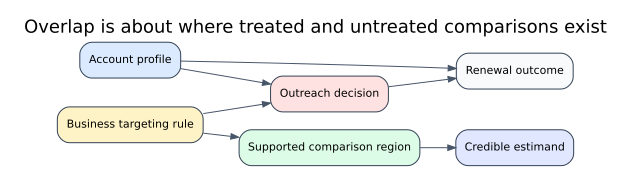

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
overlap_edges = [
    ("Account profile", "Outreach decision"),
    ("Account profile", "Renewal outcome"),
    ("Business targeting rule", "Outreach decision"),
    ("Business targeting rule", "Supported comparison region"),
    ("Outreach decision", "Renewal outcome"),
    ("Supported comparison region", "Credible estimand"),
]

make_dag(
    overlap_edges,
    title="Overlap is about where treated and untreated comparisons exist",
    node_colors={
        "Account profile": "#dbeafe",
        "Business targeting rule": "#fef3c7",
        "Supported comparison region": "#dcfce7",
        "Credible estimand": "#e0e7ff",
        "Outreach decision": "#fee2e2",
        "Renewal outcome": "#f8fafc",
    },
)

The graph separates two ideas that are often blurred together:

1. **Confounding**: account profile affects both outreach and renewal outcome.
2. **Overlap**: for some account profiles, one of the treatment conditions may be rare or absent.

Adjustment methods address confounding only in regions where comparison data exist. If the organization never withholds outreach from a certain type of account, then the untreated potential outcome for that type is not represented by observed untreated accounts. A model can extrapolate, but that extrapolation is no longer primarily a design-based comparison.

## 2. Positivity, Common Support, and Practical Overlap

Let $D_i$ be the treatment indicator and $X_i$ be the covariates we adjust for. The propensity score is:

$$
e(X_i) = P(D_i = 1 \mid X_i).
$$

For the full-population ATE to be identified from observational data under ignorability, we need positivity:

$$
0 < P(D_i = 1 \mid X_i = x) < 1
$$

for every covariate profile $x$ in the target population. A stronger finite-sample version says the probability should be bounded away from zero and one:

$$
\epsilon < e(X_i) < 1 - \epsilon
$$

for some meaningful $\epsilon > 0$.

Westreich and Cole (2010) discuss positivity as the requirement that, within the covariate patterns used for adjustment, both exposed and unexposed participants are possible. Petersen et al. (2010) emphasize that violations can be structural, where treatment is impossible by design, or practical, where a treatment level is theoretically possible but sparsely observed.

In industry language:

- **Structural positivity problem**: the business rule forbids one action for some customer type. Example: free-tier customers are never assigned a dedicated enterprise success manager.
- **Practical overlap problem**: both actions are possible, but historical data contain very few examples of one action. Example: almost every large, high-risk enterprise account receives high-touch outreach.

## 3. Running Example: Targeted Renewal Outreach

We will simulate a SaaS renewal setting. The company wants to estimate the effect of proactive outreach on a renewal-value outcome.

The historical targeting rule is intentionally aggressive:

- high churn-risk accounts are much more likely to receive outreach;
- enterprise and mid-market accounts are more likely to receive outreach;
- large contracts receive extra attention;
- low-usage accounts receive more attention;
- a strict business rule pushes enterprise accounts with elevated churn risk and very high-value, high-risk accounts toward treatment.

The treatment effect is heterogeneous. Outreach is more useful for larger and enterprise accounts, but less useful for accounts with very high churn risk, where some problems may be too severe for outreach alone to solve.

**Dataset and experiment setup.** The overlap example represents renewal outreach targeted by risk and commercial priority. Some customers are so likely to receive outreach, or so unlikely to receive it, that the data contain weak comparisons for them. This is a common industry problem because business rules intentionally concentrate interventions where teams believe they matter most. The simulation includes observed confounders, treatment assignment, outcomes, and a known treatment effect. Its purpose is to show that trimming is not just a numerical convenience; it changes the population for which the causal contrast is credible.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_overlap_problem(n=9000, seed=6060):
    """Generate an observational outreach setting with weak overlap and known effects.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(["self_serve", "mid_market", "enterprise"], p=[0.46, 0.34, 0.20], size=n)
    segment_score = pd.Series(segment).map({"self_serve": 0.0, "mid_market": 0.5, "enterprise": 1.0}).to_numpy()

    tenure = np.clip(rng.gamma(shape=2.0, scale=8.0, size=n), 1, 60)
    seats = np.clip(np.exp(rng.normal(2.4 + 0.55 * segment_score, 0.75, n)), 2, 160)
    usage = np.clip(rng.normal(42 + 0.33 * tenure + 8 * segment_score + 0.15 * seats, 13, n), 2, 140)
    contract_value = np.clip(
        rng.lognormal(3.6 + 0.32 * segment_score + 0.005 * seats, 0.55, n),
        15,
        800,
    )

    health_score = expit(
        -0.7
        + 0.045 * usage
        + 0.004 * contract_value
        - 0.015 * tenure
        + rng.normal(0, 0.7, n)
    )
    churn_risk = expit(
        1.8
        - 0.070 * usage
        - 0.006 * contract_value
        + 0.018 * tenure
        - 1.20 * (segment == "enterprise")
        + rng.normal(0, 0.9, n)
    )

    strict_rule = (
        ((segment == "enterprise") & (churn_risk > 0.10))
        | ((contract_value > 150) & (churn_risk > 0.25))
    ).astype(float)

    true_propensity = expit(
        -3.7
        + 7.8 * churn_risk
        + 1.8 * (segment == "enterprise")
        + 0.85 * (segment == "mid_market")
        + 0.010 * contract_value
        - 0.035 * usage
        + 1.6 * strict_rule
    )
    treated = rng.binomial(1, true_propensity)

    y0 = (
        48
        + 0.10 * usage
        + 0.025 * contract_value
        + 0.08 * tenure
        + 4.0 * segment_score
        + 9.0 * health_score
        - 17.0 * churn_risk
        + rng.normal(0, 4.8, n)
    )

    treatment_effect = (
        2.2
        + 1.25 * (segment == "enterprise")
        + 0.55 * (segment == "mid_market")
        + 0.010 * usage
        - 1.80 * churn_risk
        + 0.0015 * contract_value
    )
    outcome = y0 + treatment_effect * treated

    return pd.DataFrame({
        "segment": segment,
        "tenure": tenure,
        "seats": seats,
        "usage": usage,
        "contract_value": contract_value,
        "health_score": health_score,
        "churn_risk": churn_risk,
        "strict_targeting_rule": strict_rule,
        "true_propensity": true_propensity,
        "treated": treated,
        "outcome": outcome,
        "outcome_without_treatment": y0,
        "true_individual_effect": treatment_effect,
    })


df = simulate_overlap_problem()
true_ate = df["true_individual_effect"].mean()
naive_effect = weighted_difference(df)

summary = pd.DataFrame({
    "quantity": [
        "Number of accounts",
        "Share receiving outreach",
        "True full-population ATE",
        "Naive treated-control difference",
        "Naive bias vs full ATE",
    ],
    "value": [
        len(df),
        df["treated"].mean(),
        true_ate,
        naive_effect,
        naive_effect - true_ate,
    ],
})

smart_display(summary)
smart_display(df.head())

,quantity,value
0,Number of accounts,9000.000000
1,Share receiving outreach,0.111222
2,True full-population ATE,2.943000
3,Naive treated-control difference,-4.270620
4,Naive bias vs full ATE,-7.213620


,segment,tenure,seats,usage,contract_value,health_score,churn_risk,strict_targeting_rule,true_propensity,treated,outcome,outcome_without_treatment,true_individual_effect
0,mid_market,9.881,25.496,54.131,30.685,0.957,0.070,0.0,0.020,0,59.326,59.326,3.211
1,self_serve,10.348,4.721,53.927,20.495,0.815,0.120,0.0,0.012,0,56.195,56.195,2.554
2,self_serve,1.858,13.923,50.856,25.106,0.909,0.053,0.0,0.008,0,57.788,57.788,2.651
3,enterprise,9.483,32.792,56.431,162.853,0.949,0.028,0.0,0.116,0,73.764,73.764,4.208
4,mid_market,10.821,13.193,28.404,26.140,0.774,0.466,0.0,0.512,0,45.314,45.314,2.235


The naive treated-control comparison has the wrong sign in this simulation. The sign reversal appears because outreach is targeted toward accounts that were already at higher risk.

This is exactly the kind of setting where observational causal inference can be valuable. But before fitting estimators, we have to ask whether the targeted assignment rule left enough untreated examples among high-priority accounts and enough treated examples among lower-priority accounts.

## 4. Estimate the Propensity Score

In a real project, the true assignment probability is unknown. We estimate it from observed covariates. Here we fit a logistic propensity model using variables that would plausibly be logged before the outreach decision.

The model is not the estimand. It is a diagnostic device and a design tool. If the fitted scores reveal that large regions have scores near zero or one, the analysis has a support problem even before we look at outcomes.

In [5]:
# Fit the statistical model and collect estimates used in the following interpretation.
ps_model = smf.glm(
    "treated ~ churn_risk + health_score + usage + contract_value + tenure + seats + strict_targeting_rule + C(segment)",
    data=df,
    family=sm.families.Binomial(),
).fit(maxiter=100)

df["ps_hat"] = clip_prob(ps_model.predict(df))
df["ate_weight"] = ate_weights(df["treated"], df["ps_hat"])
df["att_weight"] = att_weights(df["treated"], df["ps_hat"])
df["overlap_weight"] = overlap_weights(df["treated"], df["ps_hat"])

auc = roc_auc_score(df["treated"], df["ps_hat"])
ps_summary = pd.DataFrame({
    "quantity": [
        "Propensity model AUC",
        "Minimum estimated propensity",
        "1st percentile estimated propensity",
        "Median estimated propensity",
        "99th percentile estimated propensity",
        "Maximum estimated propensity",
    ],
    "value": [
        auc,
        df["ps_hat"].min(),
        df["ps_hat"].quantile(0.01),
        df["ps_hat"].median(),
        df["ps_hat"].quantile(0.99),
        df["ps_hat"].max(),
    ],
})

smart_display(ps_summary)
smart_display(ps_model.summary2().tables[1].round(3))

,quantity,value
0,Propensity model AUC,0.877663
1,Minimum estimated propensity,0.001482
2,1st percentile estimated propensity,0.003424
3,Median estimated propensity,0.036045
4,99th percentile estimated propensity,0.862174
5,Maximum estimated propensity,0.992650


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-2.147,0.318,-6.750,0.000,-2.771,-1.524
C(segment)[T.mid_market],-0.926,0.152,-6.091,0.000,-1.223,-0.628
C(segment)[T.self_serve],-1.804,0.167,-10.799,0.000,-2.131,-1.476
churn_risk,7.606,0.297,25.634,0.000,7.024,8.187
health_score,0.183,0.339,0.540,0.589,-0.482,0.848
usage,-0.031,0.005,-6.378,0.000,-0.041,-0.022
contract_value,0.009,0.001,8.105,0.000,0.007,0.012
tenure,-0.004,0.004,-0.907,0.364,-0.012,0.004
seats,0.001,0.003,0.238,0.812,-0.005,0.006
strict_targeting_rule,1.667,0.177,9.391,0.000,1.319,2.014


A high propensity-model AUC can be a warning sign for causal adjustment. For prediction, high AUC means the model separates treated from untreated accounts well. For causal adjustment, strong separation suggests that the historical process made treatment almost deterministic for some accounts.

When propensity scores are near zero, treated observations in that region receive very large ATE weights. When propensity scores are near one, control observations in that region receive very large ATE weights. Those large weights are the estimator's attempt to reconstruct a comparison that the data barely contain.

## 5. Visualize Propensity-Score Overlap

The fastest first diagnostic is a distribution plot of the estimated propensity score by treatment group. We want substantial overlap, not just two distributions that touch at the edges.

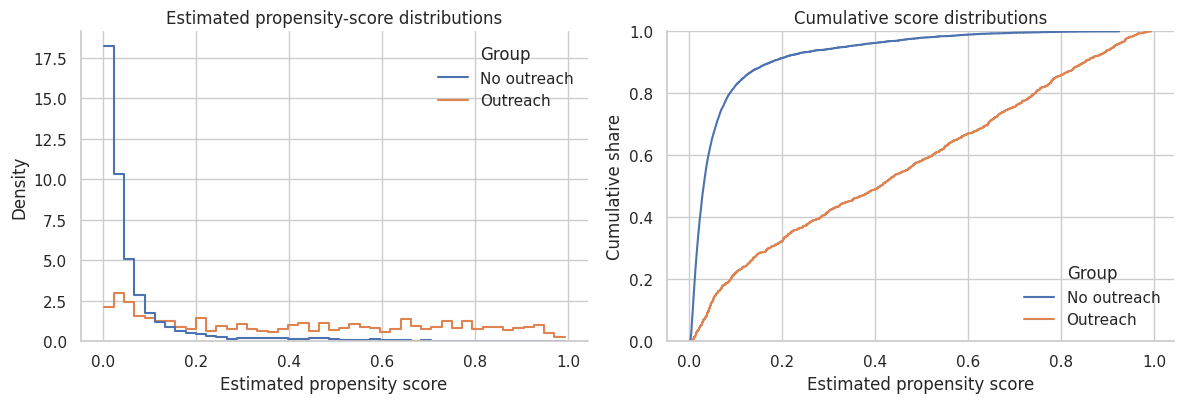

In [6]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_frame = df.assign(outreach_status=df["treated"].map({0: "No outreach", 1: "Outreach"}))

sns.histplot(
    data=plot_frame,
    x="ps_hat",
    hue="outreach_status",
    hue_order=["No outreach", "Outreach"],
    stat="density",
    common_norm=False,
    bins=45,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("Estimated propensity-score distributions")
axes[0].set_xlabel("Estimated propensity score")

sns.ecdfplot(
    data=plot_frame,
    x="ps_hat",
    hue="outreach_status",
    hue_order=["No outreach", "Outreach"],
    ax=axes[1],
)
axes[1].set_title("Cumulative score distributions")
axes[1].set_xlabel("Estimated propensity score")
axes[1].set_ylabel("Cumulative share")

for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Group")
        legend.set_frame_on(False)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The untreated group has a large mass at low estimated treatment probabilities. The treated group is shifted heavily toward higher scores. The two groups overlap, but the overlap is not evenly distributed.

This has a practical interpretation: many low-risk or lower-value accounts were almost never contacted, and many high-priority accounts were usually contacted. A full-population ATE asks us to learn what outreach would do for all accounts, including account profiles where the historical data contain thin comparisons.

## 6. Common-Support Tables

Plots are useful, but decision reviews need tables. We can summarize overlap by treatment group, then count treated and untreated units inside score bins.

In [7]:
# Build the summary table used to connect the calculation back to the design question.
score_support = (
    df.groupby("treated")["ps_hat"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])
    .rename(index={0: "No outreach", 1: "Outreach"})
)

treated_scores = df.loc[df["treated"] == 1, "ps_hat"]
control_scores = df.loc[df["treated"] == 0, "ps_hat"]
common_lower = max(treated_scores.min(), control_scores.min())
common_upper = min(treated_scores.max(), control_scores.max())
inside_common_support = df["ps_hat"].between(common_lower, common_upper)

support_summary = pd.DataFrame({
    "quantity": [
        "Lower edge of empirical common support",
        "Upper edge of empirical common support",
        "Share of all accounts inside empirical common support",
        "Share of outreach accounts inside empirical common support",
        "Share of no-outreach accounts inside empirical common support",
    ],
    "value": [
        common_lower,
        common_upper,
        inside_common_support.mean(),
        inside_common_support[df["treated"] == 1].mean(),
        inside_common_support[df["treated"] == 0].mean(),
    ],
})

smart_display(score_support)
smart_display(support_summary)

,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max
treated,,,,,,,,,,,,
No outreach,7999.0,0.072,0.117,0.001,0.003,0.006,0.008,0.031,0.175,0.335,0.610,0.924
Outreach,1001.0,0.421,0.301,0.006,0.010,0.024,0.042,0.410,0.849,0.913,0.962,0.993


,quantity,value
0,Lower edge of empirical common support,0.005579
1,Upper edge of empirical common support,0.923849
2,Share of all accounts inside empirical common support,0.953000
3,Share of outreach accounts inside empirical common support,0.960040
4,Share of no-outreach accounts inside empirical common support,0.952119


In Common-Support Tables, the table shows whether the comparison is supported by nearby observed units or by extrapolation. Weak overlap narrows the population we can speak about.

In [8]:
# Build the summary table used to connect the calculation back to the design question.
score_bins = pd.IntervalIndex.from_breaks([0, 0.01, 0.03, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00], closed="left")
score_bin_frame = df.copy()
score_bin_frame["score_bin"] = pd.cut(score_bin_frame["ps_hat"], bins=score_bins)

bin_support = (
    score_bin_frame
    .groupby("score_bin", observed=True)
    .agg(
        accounts=("treated", "size"),
        outreach=("treated", "sum"),
        no_outreach=("treated", lambda x: (1 - x).sum()),
        outreach_share=("treated", "mean"),
        mean_contract_value=("contract_value", "mean"),
        mean_churn_risk=("churn_risk", "mean"),
    )
    .reset_index()
)
bin_support["min_group_count"] = bin_support[["outreach", "no_outreach"]].min(axis=1)
bin_support["support_flag"] = np.where(bin_support["min_group_count"] >= 30, "usable", "thin")

smart_display(bin_support)

,score_bin,accounts,outreach,no_outreach,outreach_share,mean_contract_value,mean_churn_risk,min_group_count,support_flag
0,"[0.0, 0.01)",1235,10,1225,0.008,39.774,0.046,10,thin
1,"[0.01, 0.03)",2729,56,2673,0.021,49.951,0.080,56,usable
2,"[0.03, 0.05)",1422,62,1360,0.044,57.339,0.112,62,usable
3,"[0.05, 0.1)",1442,93,1349,0.064,61.798,0.168,93,usable
4,"[0.1, 0.2)",806,102,704,0.127,63.264,0.279,102,usable
5,"[0.2, 0.4)",556,167,389,0.300,55.063,0.378,167,usable
6,"[0.4, 0.6)",395,181,214,0.458,50.925,0.402,181,usable
7,"[0.6, 0.8)",263,189,74,0.719,51.160,0.559,74,usable
8,"[0.8, 1.0)",152,141,11,0.928,63.643,0.690,11,thin


The empirical common-support interval can look deceptively comforting because almost everyone may fall between the smallest treated score and the largest control score. But common support in the strict min-max sense is weak. The more relevant question is local: within a score region, do we have enough observations from both groups to make a stable comparison?

The score-bin table is more operational. Bins with very few treated accounts or very few control accounts are places where estimates will lean heavily on modeling choices or large weights.

## 7. Extreme Weights as an Overlap Diagnostic

ATE inverse probability weights are:

$$
w_i^{ATE} = \frac{D_i}{\hat e(X_i)} + \frac{1 - D_i}{1 - \hat e(X_i)}.
$$

These weights create a pseudo-population representing the full target population. But when scores are close to zero or one, the denominator becomes small. Extreme weights are therefore not just a numerical inconvenience. They are a signal that the requested target population is poorly supported by the observed design.

Petersen et al. (2010) discuss weight truncation as a practical response to positivity problems, but emphasize the bias-variance tradeoff. Truncation can reduce variance by limiting extreme weights, but it can also change or distort the estimand if used casually.

,design,ess,ess_share_of_n,mean,sd,p95,p99,max
0,ATE IPW,777.929,0.086,2.028,6.594,3.377,25.620,179.257
1,ATT weights,1708.177,0.190,0.215,0.444,1.000,1.463,12.132
2,Overlap weights,2324.902,0.258,0.129,0.218,0.704,0.961,0.994


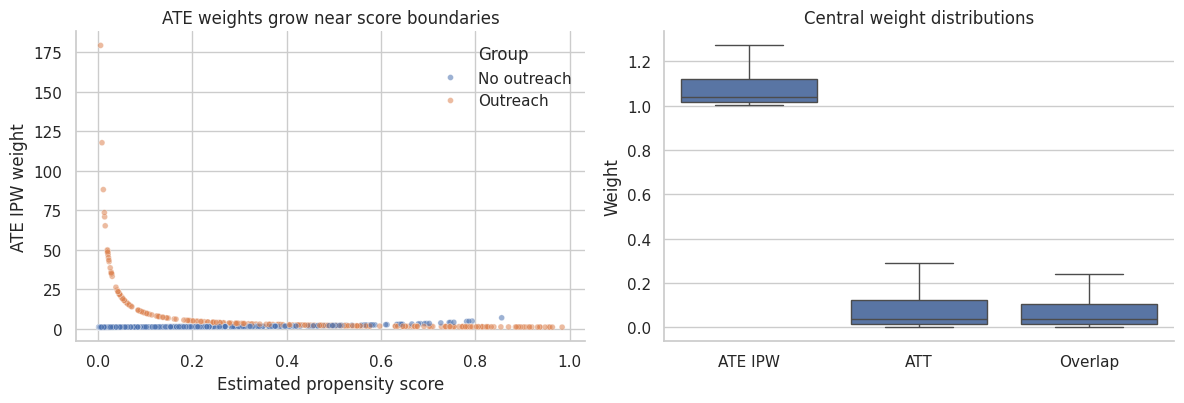

In [9]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
weight_diagnostics = pd.DataFrame([
    {"design": "ATE IPW", **weight_summary(df["ate_weight"])},
    {"design": "ATT weights", **weight_summary(df["att_weight"])},
    {"design": "Overlap weights", **weight_summary(df["overlap_weight"])},
])

smart_display(weight_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sample_for_weights = df.sample(2500, random_state=6).assign(
    outreach_status=lambda data: data["treated"].map({0: "No outreach", 1: "Outreach"})
)
sns.scatterplot(
    data=sample_for_weights,
    x="ps_hat",
    y="ate_weight",
    hue="outreach_status",
    hue_order=["No outreach", "Outreach"],
    alpha=0.55,
    s=18,
    ax=axes[0],
)
axes[0].set_title("ATE weights grow near score boundaries")
axes[0].set_xlabel("Estimated propensity score")
axes[0].set_ylabel("ATE IPW weight")
axes[0].legend(title="Group", frameon=False)

plot_weight_df = df[["ate_weight", "att_weight", "overlap_weight"]].melt(
    var_name="weight_type",
    value_name="weight",
)
sns.boxplot(
    data=plot_weight_df,
    x="weight_type",
    y="weight",
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Central weight distributions")
axes[1].set_xlabel("")
axes[1].set_ylabel("Weight")
axes[1].set_xticklabels(["ATE IPW", "ATT", "Overlap"])

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The ATE weights are much more variable than the ATT or overlap weights. That is expected here. The ATE tries to represent everyone, including low-score accounts that were rarely treated and high-score accounts that were rarely untreated.

The effective sample size is especially useful. It answers: after weighting, how many equally weighted observations would carry about the same information? A design can have thousands of rows but only a small effective sample if a few observations dominate the weighted analysis.

## 8. Build a Balance Frame

Before comparing estimands, we need a consistent balance frame. This includes the continuous confounders and segment indicators.

,design,max_abs_smd,mean_abs_smd,covariates_above_0.10,ess,ess_share_of_n,max_weight,p99_weight
0,Raw groups,1.284e+00,4.111e-01,6,NaN,NaN,NaN,NaN
1,ATE IPW,7.663e-02,1.973e-02,0,777.929,0.086,179.257,25.620
2,ATT weights,9.397e-02,4.372e-02,0,1708.177,0.190,12.132,1.463
3,Overlap weights,1.537e-14,4.864e-15,0,2324.902,0.258,0.994,0.961


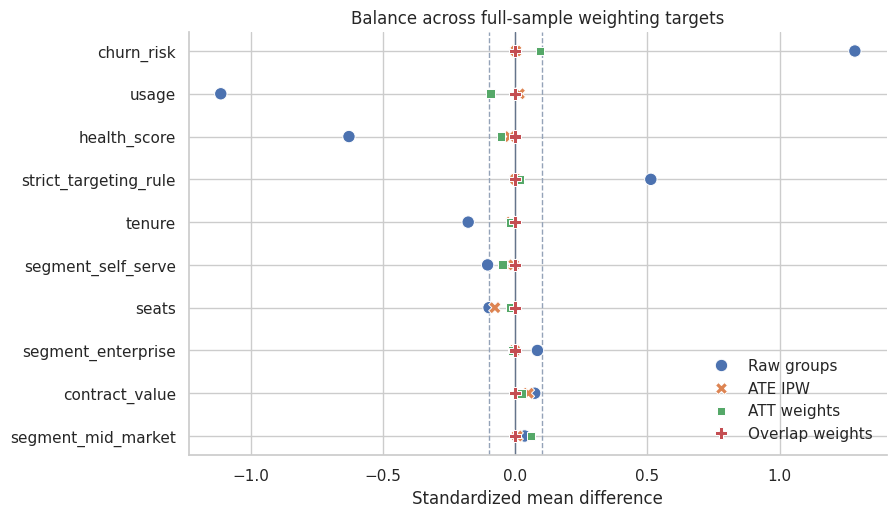

In [10]:
# Build the summary table used to connect the calculation back to the design question.
segment_dummies = pd.get_dummies(df["segment"], prefix="segment", dtype=float)
balance_frame = pd.concat(
    [
        df[[
            "treated",
            "churn_risk",
            "health_score",
            "usage",
            "contract_value",
            "tenure",
            "seats",
            "strict_targeting_rule",
        ]],
        segment_dummies,
    ],
    axis=1,
)
balance_covariates = [c for c in balance_frame.columns if c != "treated"]

balance_tables = {
    "Raw groups": standardized_mean_differences(balance_frame, balance_covariates),
    "ATE IPW": standardized_mean_differences(balance_frame, balance_covariates, weights=df["ate_weight"]),
    "ATT weights": standardized_mean_differences(balance_frame, balance_covariates, weights=df["att_weight"]),
    "Overlap weights": standardized_mean_differences(balance_frame, balance_covariates, weights=df["overlap_weight"]),
}

dashboard = pd.DataFrame([
    {"design": label, **balance_dashboard(table, None if label == "Raw groups" else df[{"ATE IPW": "ate_weight", "ATT weights": "att_weight", "Overlap weights": "overlap_weight"}[label]])}
    for label, table in balance_tables.items()
])

smart_display(dashboard)
plot_love(balance_tables, title="Balance across full-sample weighting targets", figsize=(9, 5.5))

Balance and overlap diagnostics should be read together.

A design may balance covariates well but still have extreme weights. That means the estimate depends on a small amount of information. A design may have stable weights but target a different population. Overlap weights often look attractive because they downweight the boundary regions, but that attractiveness comes from changing the target toward accounts where either outreach decision was plausible.

## 9. Estimands Before Estimators

The most important habit in this notebook is to separate the **estimand** from the **estimator**.

For a binary treatment, several common targets are:

$$
ATE = E[Y(1) - Y(0)]
$$

$$
ATT = E[Y(1) - Y(0) \mid D = 1]
$$

A trimmed ATE restricts the target to units whose estimated propensity scores lie inside a chosen interval:

$$
ATE_{\alpha} = E[Y(1) - Y(0) \mid \alpha \le \hat e(X) \le 1 - \alpha]
$$

Overlap weights target a population with density proportional to:

$$
h(X) = e(X)\{1 - e(X)\}.
$$

For treated units the overlap weight is $1 - \hat e(X_i)$, and for untreated units it is $\hat e(X_i)$. Li, Morgan, and Zaslavsky (2017) show that these weights emphasize units near propensity $1/2$ and are bounded, which makes them less sensitive to extreme weights than ordinary IPW.

In [11]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def true_weighted_effect(frame, target_weights=None):
    """Compute true weighted effect for 06. Overlap and Trimming.

    Args:
        frame: Analysis DataFrame to copy, transform, summarize, or model.
        target_weights: Weights defining the target population or estimand.

    Returns:
        float: True weighted estimand under the target weights.
    """
    if target_weights is None:
        target_weights = np.ones(len(frame))
    return weighted_mean(frame["true_individual_effect"], target_weights)


target_comparison = pd.DataFrame([
    {
        "target": "Full population ATE",
        "estimate": weighted_difference(df, weights=df["ate_weight"]),
        "true_target_effect": true_weighted_effect(df),
        "effective_sample_size": effective_sample_size(df["ate_weight"]),
        "max_weight": df["ate_weight"].max(),
    },
    {
        "target": "ATT among outreach accounts",
        "estimate": weighted_difference(df, weights=df["att_weight"]),
        "true_target_effect": true_weighted_effect(df, target_weights=df["treated"]),
        "effective_sample_size": effective_sample_size(df["att_weight"]),
        "max_weight": df["att_weight"].max(),
    },
    {
        "target": "Overlap population",
        "estimate": weighted_difference(df, weights=df["overlap_weight"]),
        "true_target_effect": true_weighted_effect(df, target_weights=df["ps_hat"] * (1 - df["ps_hat"])),
        "effective_sample_size": effective_sample_size(df["overlap_weight"]),
        "max_weight": df["overlap_weight"].max(),
    },
])
target_comparison["estimation_error_vs_target"] = target_comparison["estimate"] - target_comparison["true_target_effect"]

smart_display(target_comparison)

,target,estimate,true_target_effect,effective_sample_size,max_weight,estimation_error_vs_target
0,Full population ATE,2.091,2.943,777.929,179.257,-0.852
1,ATT among outreach accounts,1.963,2.451,1708.177,12.132,-0.489
2,Overlap population,2.440,2.669,2324.902,0.994,-0.229


The estimates are not answering the same question. The ATT emphasizes accounts that actually received outreach. The overlap target emphasizes accounts where the historical process was closer to equipoise. The full-population ATE asks about all accounts, including low-score accounts that rarely received outreach.

In this simulation, we can compute the true target effect because we generated both potential outcomes. In real projects, we cannot. But the simulation teaches the discipline: when we change weights or trim rows, we should update the sentence that describes the causal question.

## 10. Trimming by Propensity Score

A common response to weak overlap is to drop observations whose estimated propensity scores are too close to zero or one. Crump et al. (2009) formalized this idea as a way to improve precision under limited overlap by changing the target population.

For a simple symmetric trimming rule, keep accounts satisfying:

$$
\alpha \le \hat e(X_i) \le 1 - \alpha.
$$

The choice of $\alpha$ is a design choice. It should be justified by diagnostics and domain context, not chosen after checking which estimate is most convenient.

In [12]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def evaluate_trim(alpha):
    """Evaluate overlap, balance, weights, and effect estimates after trimming.

    Args:
        alpha: Type-I error level used for testing or intervals.

    Returns:
        pandas.DataFrame or dict: Scenario results used for comparison in the notebook.
    """
    mask = df["ps_hat"].between(alpha, 1 - alpha)
    sub = df.loc[mask].copy()
    sub_balance = balance_frame.loc[mask].copy()
    w = ate_weights(sub["treated"], sub["ps_hat"])
    balance = standardized_mean_differences(sub_balance, balance_covariates, weights=w)
    return {
        "alpha": alpha,
        "retained_n": len(sub),
        "retained_share": len(sub) / len(df),
        "outreach_n": int(sub["treated"].sum()),
        "no_outreach_n": int((1 - sub["treated"]).sum()),
        "outreach_share": sub["treated"].mean(),
        "estimate": weighted_difference(sub, weights=w),
        "true_trimmed_effect": sub["true_individual_effect"].mean(),
        "estimation_error_vs_trimmed_target": weighted_difference(sub, weights=w) - sub["true_individual_effect"].mean(),
        "true_effect_shift_vs_full_ATE": sub["true_individual_effect"].mean() - true_ate,
        "ess": effective_sample_size(w),
        "ess_share_of_retained": effective_sample_size(w) / len(sub),
        "max_weight": np.max(w),
        "p99_weight": np.quantile(w, 0.99),
        "max_abs_smd": balance["abs_smd"].max(),
        "mean_abs_smd": balance["abs_smd"].mean(),
    }

trim_grid = [0.00, 0.01, 0.03, 0.05, 0.10, 0.15, 0.20]
trim_results = pd.DataFrame([evaluate_trim(alpha) for alpha in trim_grid])

smart_display(trim_results)

,alpha,retained_n,retained_share,outreach_n,no_outreach_n,outreach_share,estimate,true_trimmed_effect,estimation_error_vs_trimmed_target,true_effect_shift_vs_full_ATE,ess,ess_share_of_retained,max_weight,p99_weight,max_abs_smd,mean_abs_smd
0,0.000000,9000,1.000000,1001,7999,0.111222,2.090513,2.943000,-0.852487,0.000000,777.928589,0.086437,179.257445,25.619613,0.076626,0.019730
1,0.010000,7764,0.862667,990,6774,0.127512,2.351478,2.941999,-0.590521,-0.001001,948.305287,0.122141,99.838652,25.857962,0.059222,0.023283
2,0.030000,5030,0.558889,929,4101,0.184692,2.484650,2.838885,-0.354235,-0.104115,1318.113692,0.262050,33.198743,21.680653,0.059239,0.023078
3,0.050000,3597,0.399667,856,2741,0.237976,2.552996,2.684884,-0.131888,-0.258116,1413.123602,0.392862,19.997542,15.151769,0.062244,0.031326
4,0.100000,2110,0.234444,719,1391,0.340758,2.285543,2.452991,-0.167448,-0.490009,1358.204465,0.643699,9.975942,8.420539,0.047206,0.021685
5,0.150000,1553,0.172556,617,936,0.397296,2.061630,2.378927,-0.317297,-0.564073,1208.485830,0.778162,6.658311,5.928317,0.101013,0.036235
6,0.200000,1214,0.134889,537,677,0.442339,2.609289,2.373675,0.235614,-0.569325,1026.081480,0.845207,4.982309,4.895307,0.108190,0.032534


In Trimming by Propensity Score, the table asks whether adjustment has made the comparison more believable. Good balance strengthens the observed-data comparison; poor balance means the estimate leans heavily on modeling.

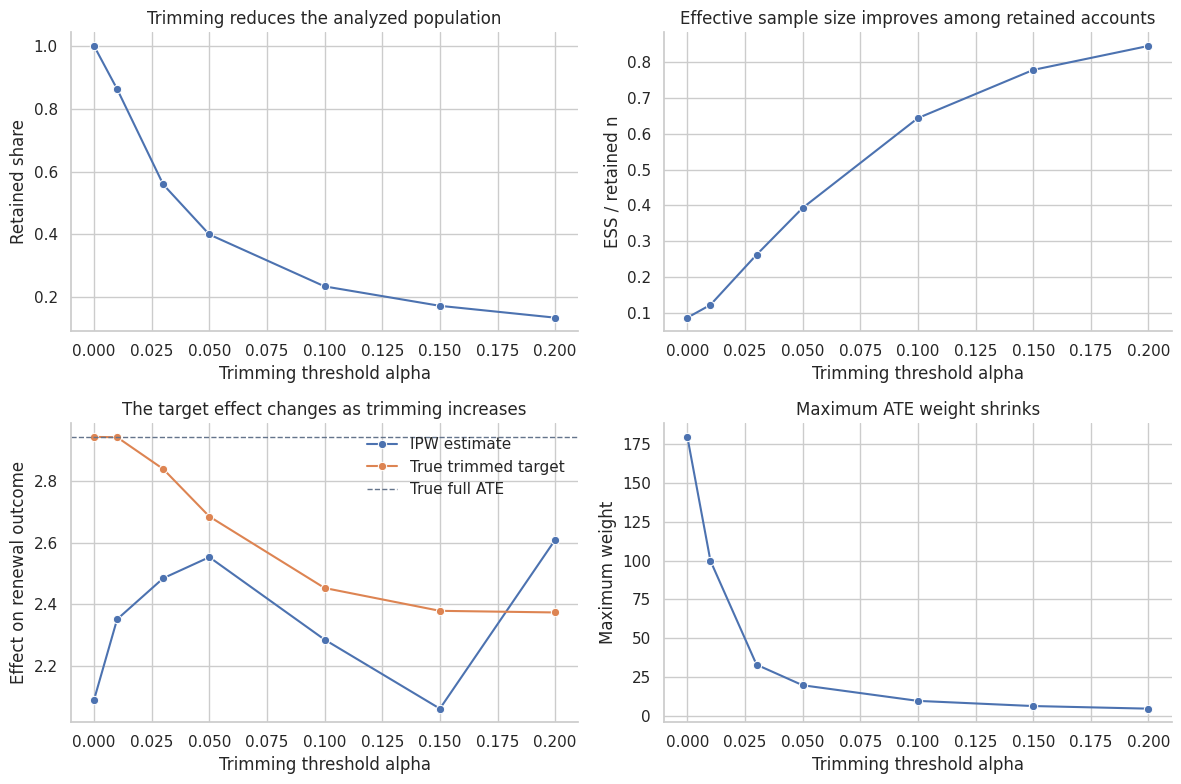

In [13]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.lineplot(data=trim_results, x="alpha", y="retained_share", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Trimming reduces the analyzed population")
axes[0, 0].set_ylabel("Retained share")

sns.lineplot(data=trim_results, x="alpha", y="ess_share_of_retained", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Effective sample size improves among retained accounts")
axes[0, 1].set_ylabel("ESS / retained n")

sns.lineplot(data=trim_results, x="alpha", y="estimate", marker="o", label="IPW estimate", ax=axes[1, 0])
sns.lineplot(data=trim_results, x="alpha", y="true_trimmed_effect", marker="o", label="True trimmed target", ax=axes[1, 0])
axes[1, 0].axhline(true_ate, color="#64748b", linestyle="--", linewidth=1, label="True full ATE")
axes[1, 0].set_title("The target effect changes as trimming increases")
axes[1, 0].set_ylabel("Effect on renewal outcome")
axes[1, 0].legend(frameon=False)

sns.lineplot(data=trim_results, x="alpha", y="max_weight", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Maximum ATE weight shrinks")
axes[1, 1].set_ylabel("Maximum weight")

for ax in axes.flat:
    ax.set_xlabel("Trimming threshold alpha")
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Trimming stabilizes the design by removing accounts with very low or very high estimated treatment probabilities. As $\alpha$ increases, the maximum weight falls and the effective sample size among retained accounts improves.

But the true target effect also changes. In this simulation, the heavily trimmed population has a lower average treatment effect than the full population because it contains fewer high-value enterprise accounts and fewer very low-propensity accounts. That is the key lesson: trimming is not merely deleting inconvenient rows. It is redefining the population.

## 11. Who Gets Removed?

A trim rule should be translated back into business language. Stakeholders rarely think in propensity-score intervals. They think in customer segments, contract size, churn risk, product usage, geography, and policy rules.

Here we compare the full population with two trimmed analysis populations.

In [14]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def population_profile(mask, label):
    """Summarize who remains in a selected overlap or trimming population.

    Args:
        mask: Boolean indicator selecting the population subset to profile.
        label: Human-readable label for the row or scenario being produced.

    Returns:
        pandas.DataFrame or pandas.Series: Display-ready summary for the notebook narrative.
    """
    frame = df.loc[mask]
    return {
        "population": label,
        "n": len(frame),
        "outreach_share": frame["treated"].mean(),
        "enterprise_share": (frame["segment"] == "enterprise").mean(),
        "mid_market_share": (frame["segment"] == "mid_market").mean(),
        "self_serve_share": (frame["segment"] == "self_serve").mean(),
        "mean_contract_value": frame["contract_value"].mean(),
        "mean_usage": frame["usage"].mean(),
        "mean_churn_risk": frame["churn_risk"].mean(),
        "mean_true_effect": frame["true_individual_effect"].mean(),
    }

profiles = pd.DataFrame([
    population_profile(np.ones(len(df), dtype=bool), "Full population"),
    population_profile(df["ps_hat"].between(0.03, 0.97), "Trim 0.03 to 0.97"),
    population_profile(df["ps_hat"].between(0.10, 0.90), "Trim 0.10 to 0.90"),
    population_profile(df["ps_hat"].between(0.20, 0.80), "Trim 0.20 to 0.80"),
])

smart_display(profiles)

,population,n,outreach_share,enterprise_share,mid_market_share,self_serve_share,mean_contract_value,mean_usage,mean_churn_risk,mean_true_effect
0,Full population,9000,0.111,0.200,0.341,0.458,53.437,52.943,0.169,2.943
1,Trim 0.03 to 0.97,5030,0.185,0.270,0.362,0.368,58.678,45.879,0.247,2.839
2,Trim 0.10 to 0.90,2110,0.341,0.197,0.374,0.428,57.363,39.456,0.378,2.453
3,Trim 0.20 to 0.80,1214,0.442,0.226,0.354,0.420,52.871,38.206,0.425,2.374


In Who Gets Removed, the table shows whether the comparison is supported by nearby observed units or by extrapolation. Weak overlap narrows the population we can speak about.

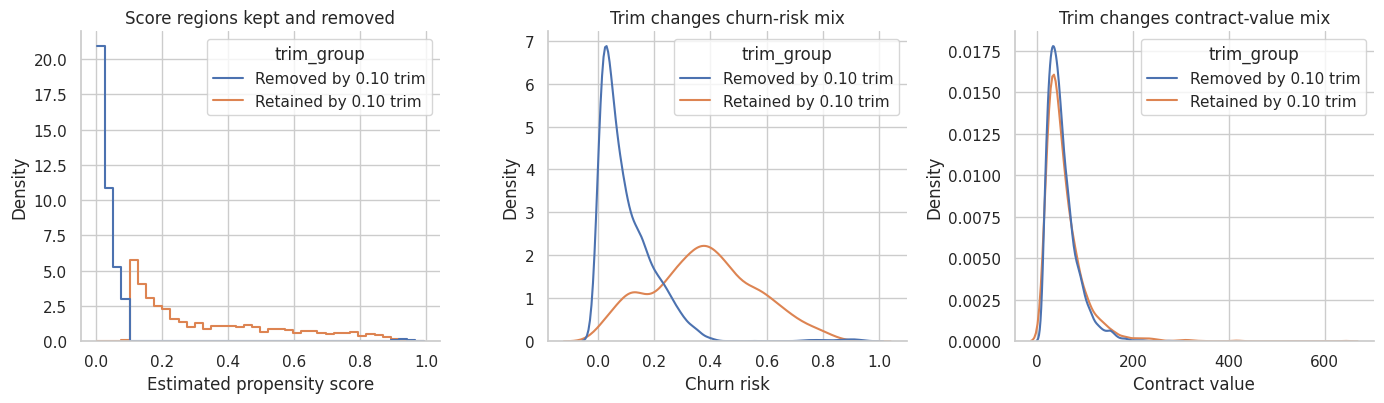

In [15]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
plot_profile = df.copy()
plot_profile["trim_group"] = "Removed by 0.10 trim"
plot_profile.loc[df["ps_hat"].between(0.10, 0.90), "trim_group"] = "Retained by 0.10 trim"

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

sns.histplot(
    data=plot_profile,
    x="ps_hat",
    hue="trim_group",
    stat="density",
    common_norm=False,
    bins=40,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("Score regions kept and removed")
axes[0].set_xlabel("Estimated propensity score")

sns.kdeplot(
    data=plot_profile,
    x="churn_risk",
    hue="trim_group",
    common_norm=False,
    fill=False,
    ax=axes[1],
)
axes[1].set_title("Trim changes churn-risk mix")
axes[1].set_xlabel("Churn risk")

sns.kdeplot(
    data=plot_profile,
    x="contract_value",
    hue="trim_group",
    common_norm=False,
    fill=False,
    ax=axes[2],
)
axes[2].set_title("Trim changes contract-value mix")
axes[2].set_xlabel("Contract value")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The 0.10 trim does not remove a random subset of accounts. It removes many accounts in regions where the outreach decision was nearly predetermined. That changes the customer story.

A good business readout would not say: "After trimming, outreach increases renewal value by X." It would say: "Among accounts whose historical characteristics made either outreach decision reasonably plausible, outreach increases renewal value by X. This excludes accounts in the most deterministic targeting regions."

## 12. Overlap Weights as a Smooth Alternative

Trimming makes a hard decision: keep or drop. Overlap weights make a smooth decision: emphasize accounts near equipoise and downweight boundary accounts.

For a general balancing-weight target, define a target function $h(X)$. The group-specific weights are:

$$
w_i(1) = \frac{h(X_i)}{e(X_i)}, \quad w_i(0) = \frac{h(X_i)}{1 - e(X_i)}.
$$

For overlap weights, $h(X_i) = e(X_i)\{1-e(X_i)\}$, so:

$$
w_i^{OW} = D_i\{1 - \hat e(X_i)\} + (1-D_i)\hat e(X_i).
$$

The target density is highest when $\hat e(X_i)$ is near $0.5$ and lowest near the boundaries.

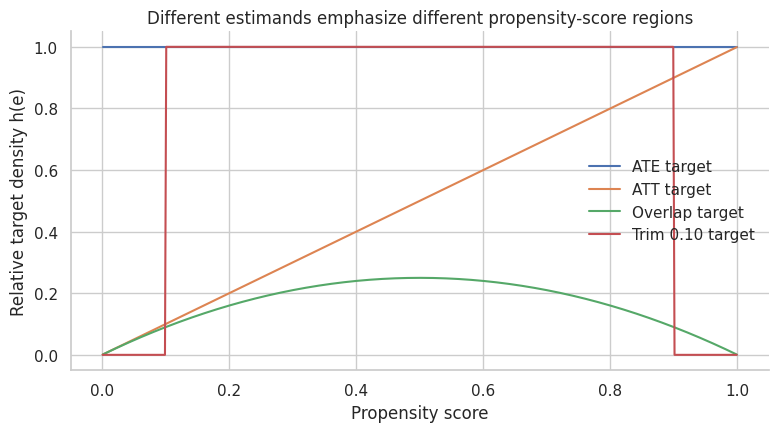

In [16]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
grid = np.linspace(0.001, 0.999, 500)
weight_functions = pd.DataFrame({
    "propensity_score": np.tile(grid, 4),
    "target": np.repeat(["ATE target", "ATT target", "Overlap target", "Trim 0.10 target"], len(grid)),
    "h_of_e": np.concatenate([
        np.ones_like(grid),
        grid,
        grid * (1 - grid),
        ((grid >= 0.10) & (grid <= 0.90)).astype(float),
    ]),
})

fig, ax = plt.subplots(figsize=(9, 4.4))
sns.lineplot(data=weight_functions, x="propensity_score", y="h_of_e", hue="target", ax=ax)
ax.set_title("Different estimands emphasize different propensity-score regions")
ax.set_xlabel("Propensity score")
ax.set_ylabel("Relative target density h(e)")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()

The ATE target weights all score regions equally in the target population. The ATT target emphasizes regions where treated units are common. The overlap target emphasizes the middle of the score distribution, where either treatment condition was plausible.

This is why overlap weights are attractive when the scientific or business question is about the "decision margin": accounts where the organization could reasonably have gone either way. They are less appropriate if leadership truly needs a full-population answer that includes regions where historical decisions were nearly deterministic.

## 13. Compare Full ATE, Trimming, and Overlap Weights

Now we combine point estimates, target effects, weight stability, and balance in one table.

In [17]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def design_row(label, frame, weights, target_weights, balance_frame_subset):
    """Create one comparison row for an overlap-weighting design.

    Args:
        label: Human-readable label for the row or scenario being produced.
        frame: Analysis DataFrame to copy, transform, or summarize.
        weights: Observation weights used to define the target pseudo-population or summary.
        target_weights: Weights defining the target estimand or target population.
        balance_frame_subset: Subset of rows used for a design-specific balance calculation.

    Returns:
        pandas.DataFrame or pandas.Series: Display-ready summary for the notebook narrative.
    """
    balance = standardized_mean_differences(balance_frame_subset, balance_covariates, weights=weights)
    return {
        "design": label,
        "n_used": len(frame),
        "estimate": weighted_difference(frame, weights=weights),
        "true_target_effect": true_weighted_effect(frame, target_weights=target_weights),
        "error_vs_target": weighted_difference(frame, weights=weights) - true_weighted_effect(frame, target_weights=target_weights),
        "ess": effective_sample_size(weights),
        "ess_share_of_n_used": effective_sample_size(weights) / len(frame),
        "max_weight": np.max(weights),
        "max_abs_smd": balance["abs_smd"].max(),
        "mean_abs_smd": balance["abs_smd"].mean(),
    }

mask_003 = df["ps_hat"].between(0.03, 0.97)
mask_010 = df["ps_hat"].between(0.10, 0.90)

comparison_rows = [
    design_row(
        "Full ATE IPW",
        df,
        df["ate_weight"].to_numpy(),
        np.ones(len(df)),
        balance_frame,
    ),
    design_row(
        "Trim 0.03 ATE IPW",
        df.loc[mask_003],
        ate_weights(df.loc[mask_003, "treated"], df.loc[mask_003, "ps_hat"]),
        np.ones(mask_003.sum()),
        balance_frame.loc[mask_003],
    ),
    design_row(
        "Trim 0.10 ATE IPW",
        df.loc[mask_010],
        ate_weights(df.loc[mask_010, "treated"], df.loc[mask_010, "ps_hat"]),
        np.ones(mask_010.sum()),
        balance_frame.loc[mask_010],
    ),
    design_row(
        "Overlap weights",
        df,
        df["overlap_weight"].to_numpy(),
        df["ps_hat"].to_numpy() * (1 - df["ps_hat"].to_numpy()),
        balance_frame,
    ),
    design_row(
        "ATT weights",
        df,
        df["att_weight"].to_numpy(),
        df["treated"].to_numpy(),
        balance_frame,
    ),
]

design_comparison = pd.DataFrame(comparison_rows)
smart_display(design_comparison)

,design,n_used,estimate,true_target_effect,error_vs_target,ess,ess_share_of_n_used,max_weight,max_abs_smd,mean_abs_smd
0,Full ATE IPW,9000,2.091,2.943,-0.852,777.929,0.086,179.257,7.663e-02,1.973e-02
1,Trim 0.03 ATE IPW,5030,2.485,2.839,-0.354,1318.114,0.262,33.199,5.924e-02,2.308e-02
2,Trim 0.10 ATE IPW,2110,2.286,2.453,-0.167,1358.204,0.644,9.976,4.721e-02,2.168e-02
3,Overlap weights,9000,2.440,2.669,-0.229,2324.902,0.258,0.994,1.537e-14,4.864e-15
4,ATT weights,9000,1.963,2.451,-0.489,1708.177,0.190,12.132,9.397e-02,4.372e-02


In Compare Full ATE, Trimming, and Overlap Weights, the table asks whether adjustment has made the comparison more believable. Good balance strengthens the observed-data comparison; poor balance means the estimate leans heavily on modeling.

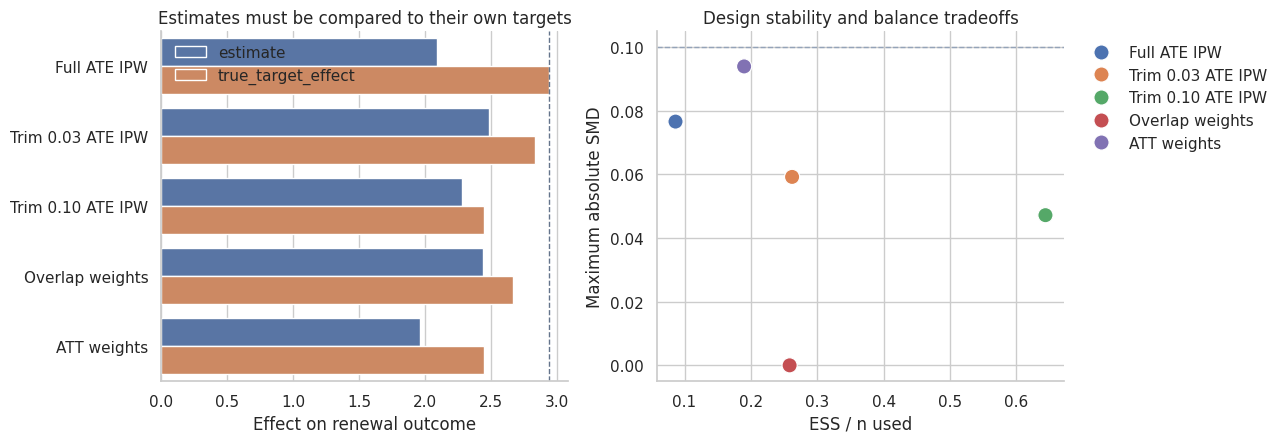

In [18]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
plot_df = design_comparison.melt(
    id_vars="design",
    value_vars=["estimate", "true_target_effect"],
    var_name="quantity",
    value_name="effect",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.barplot(data=plot_df, y="design", x="effect", hue="quantity", ax=axes[0])
axes[0].axvline(true_ate, color="#64748b", linestyle="--", linewidth=1)
axes[0].set_title("Estimates must be compared to their own targets")
axes[0].set_xlabel("Effect on renewal outcome")
axes[0].set_ylabel("")
axes[0].legend(frameon=False)

sns.scatterplot(
    data=design_comparison,
    x="ess_share_of_n_used",
    y="max_abs_smd",
    hue="design",
    s=120,
    ax=axes[1],
)
axes[1].axhline(0.10, color="#94a3b8", linestyle="--", linewidth=1)
axes[1].set_title("Design stability and balance tradeoffs")
axes[1].set_xlabel("ESS / n used")
axes[1].set_ylabel("Maximum absolute SMD")
axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

There is no universal winner. The full ATE IPW design answers the broadest question, but it is vulnerable to weak overlap. The trimmed designs are more stable, but the target population narrows. The overlap-weighted design is stable and well-aligned with the region of empirical equipoise, but it no longer represents the full customer base.

In an industry project, this table is the beginning of a conversation with stakeholders. If they need a decision for all customers, the data may be insufficient and the recommendation might be to run an experiment or collect better support. If they need a decision for accounts near the operational margin, overlap weights may be exactly the right estimand.

## 14. Sensitivity to the Trimming Threshold

Because trimming is a design choice, we should show how sensitive the conclusion is to reasonable thresholds. A result that changes dramatically across $\alpha$ values deserves caution.

,alpha,retained_share,estimate,true_trimmed_effect,estimation_error_vs_trimmed_target,true_effect_shift_vs_full_ATE,ess_share_of_retained,max_abs_smd
0,0.000000,1.000000,2.090513,2.943000,-0.852487,0.000000,0.086437,0.076626
1,0.010000,0.862667,2.351478,2.941999,-0.590521,-0.001001,0.122141,0.059222
2,0.030000,0.558889,2.484650,2.838885,-0.354235,-0.104115,0.262050,0.059239
3,0.050000,0.399667,2.552996,2.684884,-0.131888,-0.258116,0.392862,0.062244
4,0.100000,0.234444,2.285543,2.452991,-0.167448,-0.490009,0.643699,0.047206
5,0.150000,0.172556,2.061630,2.378927,-0.317297,-0.564073,0.778162,0.101013
6,0.200000,0.134889,2.609289,2.373675,0.235614,-0.569325,0.845207,0.108190


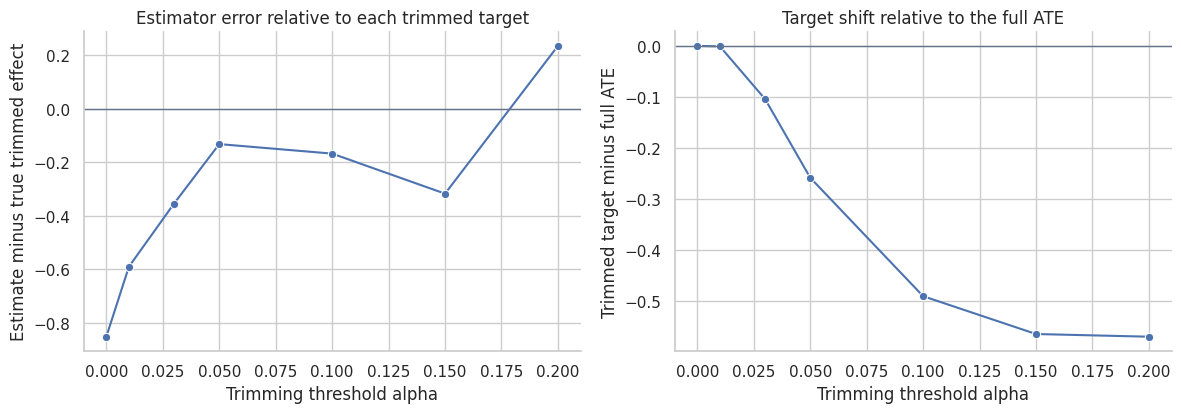

In [19]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
trim_sensitivity = trim_results[[
    "alpha",
    "retained_share",
    "estimate",
    "true_trimmed_effect",
    "estimation_error_vs_trimmed_target",
    "true_effect_shift_vs_full_ATE",
    "ess_share_of_retained",
    "max_abs_smd",
]].copy()

smart_display(trim_sensitivity)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

sns.lineplot(data=trim_sensitivity, x="alpha", y="estimation_error_vs_trimmed_target", marker="o", ax=axes[0])
axes[0].axhline(0, color="#64748b", linewidth=1)
axes[0].set_title("Estimator error relative to each trimmed target")
axes[0].set_xlabel("Trimming threshold alpha")
axes[0].set_ylabel("Estimate minus true trimmed effect")

sns.lineplot(data=trim_sensitivity, x="alpha", y="true_effect_shift_vs_full_ATE", marker="o", ax=axes[1])
axes[1].axhline(0, color="#64748b", linewidth=1)
axes[1].set_title("Target shift relative to the full ATE")
axes[1].set_xlabel("Trimming threshold alpha")
axes[1].set_ylabel("Trimmed target minus full ATE")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

This plot separates two sources of movement:

1. **Estimator error**: how far the estimator is from the target it claims to estimate.
2. **Target shift**: how much the target itself changes as the analysis population changes.

In real data we cannot observe the true target effects, but we can always report the retained population, covariate profiles, balance, and weight diagnostics. Those diagnostics help stakeholders understand whether different thresholds are telling a consistent story or whether the analysis is mostly driven by a fragile support decision.

## 15. Structural vs Practical Positivity in the Example

The strict targeting rule in our simulation is not perfectly deterministic, but it mimics a business rule that pushes a subgroup strongly toward outreach. We can inspect this subgroup directly.

,accounts,outreach_share,mean_ps,min_ps,max_ps,mean_contract_value,mean_churn_risk,mean_true_effect
strict_targeting_rule,,,,,,,,
Rule not triggered,8712,0.097,0.097,0.001,0.978,53.277,0.168,2.921
Rule triggered,288,0.542,0.542,0.213,0.993,58.295,0.194,3.596


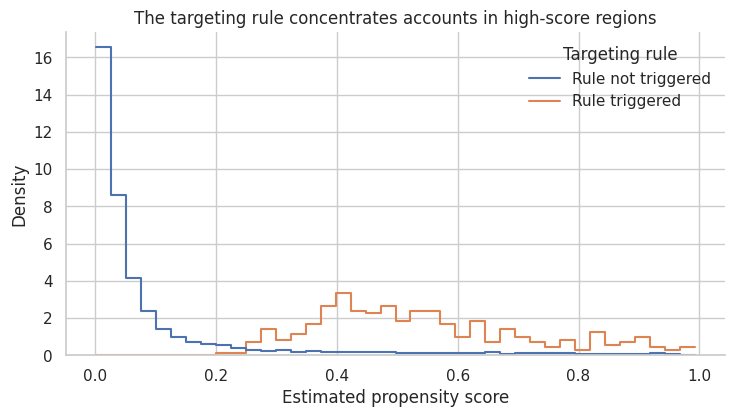

In [20]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
rule_table = (
    df.groupby("strict_targeting_rule")
    .agg(
        accounts=("treated", "size"),
        outreach_share=("treated", "mean"),
        mean_ps=("ps_hat", "mean"),
        min_ps=("ps_hat", "min"),
        max_ps=("ps_hat", "max"),
        mean_contract_value=("contract_value", "mean"),
        mean_churn_risk=("churn_risk", "mean"),
        mean_true_effect=("true_individual_effect", "mean"),
    )
    .rename(index={0.0: "Rule not triggered", 1.0: "Rule triggered"})
)

smart_display(rule_table)

rule_plot = df.assign(
    targeting_rule=df["strict_targeting_rule"].map({0.0: "Rule not triggered", 1.0: "Rule triggered"})
)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
sns.histplot(
    data=rule_plot,
    x="ps_hat",
    hue="targeting_rule",
    hue_order=["Rule not triggered", "Rule triggered"],
    stat="density",
    common_norm=False,
    bins=40,
    element="step",
    fill=False,
    ax=ax,
)
ax.set_title("The targeting rule concentrates accounts in high-score regions")
ax.set_xlabel("Estimated propensity score")
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Targeting rule")
    legend.set_frame_on(False)
sns.despine(ax=ax)
plt.show()

When a policy rule strongly determines treatment, we should not hide it inside a generic propensity model. We should name it.

A structural positivity issue often calls for a change in the research question. For example, if rule-triggered high-priority accounts are almost always contacted, historical data may not support the effect of withholding outreach from those accounts. The right next step might be a carefully governed experiment, a phased rollout, or a different target estimand.

A practical positivity issue may be less severe. If there are some untreated examples but not many, trimming, overlap weights, matching with calipers, or collecting more data may be reasonable responses.

## 16. A Practical Decision Workflow

An overlap workflow for observational industry projects can be written as a design checklist.

1. **State the original target**: full customers, treated customers, eligible customers, or decision-margin customers.
2. **Estimate treatment propensities** using pre-treatment covariates and known assignment rules.
3. **Inspect score overlap** with distributions, score-bin tables, and local treated/control counts.
4. **Inspect weights** for ESS, maximum weight, high percentiles, and concentration.
5. **Inspect balance** after applying the candidate design.
6. **Translate exclusions** into business terms if trimming or matching removes units.
7. **Rename the estimand** whenever the design changes the target population.
8. **Escalate to better data collection** when the desired target is not supported.

In [21]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def design_recommendation(row):
    """Convert overlap diagnostics into a plain-language design recommendation.

    Args:
        row: Row from a summary table used to build text or status output.

    Returns:
        pandas.DataFrame or pandas.Series: Display-ready summary for the notebook narrative.
    """
    if row["max_abs_smd"] > 0.10:
        return "Revise design: balance remains weak"
    if row["ess_share_of_n_used"] < 0.25:
        return "Caution: estimate depends on limited effective information"
    if "Trim" in row["design"]:
        return "Usable if stakeholders accept the trimmed target"
    if row["design"] == "Overlap weights":
        return "Usable for decision-margin target"
    if row["design"] == "ATT weights":
        return "Usable for treated-population target"
    return "Usable only if full-population support is defensible"

readiness = design_comparison.copy()
readiness["recommendation"] = readiness.apply(design_recommendation, axis=1)
readiness = readiness[[
    "design",
    "n_used",
    "estimate",
    "true_target_effect",
    "ess_share_of_n_used",
    "max_weight",
    "max_abs_smd",
    "recommendation",
]]

smart_display(readiness)

,design,n_used,estimate,true_target_effect,ess_share_of_n_used,max_weight,max_abs_smd,recommendation
0,Full ATE IPW,9000,2.090513,2.943000,0.086437,179.257445,0.076626,Caution: estimate depends on limited effective information
1,Trim 0.03 ATE IPW,5030,2.484650,2.838885,0.262050,33.198743,0.059239,Usable if stakeholders accept the trimmed target
2,Trim 0.10 ATE IPW,2110,2.285543,2.452991,0.643699,9.975942,0.047206,Usable if stakeholders accept the trimmed target
3,Overlap weights,9000,2.439846,2.668656,0.258322,0.994421,0.000000,Usable for decision-margin target
4,ATT weights,9000,1.962539,2.451462,0.189797,12.131831,0.093967,Caution: estimate depends on limited effective information


The recommendation column is intentionally conservative. In real work, the numerical cutoffs should be adapted to sample size, domain risk, and the cost of acting on a wrong estimate. The deeper principle is stable: do not let a clean-looking estimate outrun the support in the data.

## 17. Reporting Template

A concise overlap report might look like this:

> We estimated the probability of outreach using pre-treatment account characteristics and known targeting rules. The fitted scores showed weak full-population overlap: many accounts had very low outreach probability, and high-risk enterprise accounts had high outreach probability. Full ATE IPW produced large weights and low effective sample size. We therefore report the overlap-weighted effect as the primary observational estimate, targeting accounts whose historical characteristics made either outreach decision plausible. We also show trimmed ATE sensitivity analyses at thresholds $\alpha \in \{0.03, 0.05, 0.10\}$. These estimates should not be interpreted as effects for all accounts, especially accounts in deterministic targeting regions. A full-population answer would require stronger design support, ideally from randomization or deliberate exploration.

That paragraph does three professional things:

1. It names the diagnostic evidence.
2. It names the target population.
3. It prevents readers from overgeneralizing beyond the supported data.

## Key Takeaways

- Positivity means each treatment condition has positive probability for the covariate profiles in the target population.
- Weak overlap requires design attention. A flexible model can extrapolate, but it cannot create observed comparisons.
- Extreme IPW weights are often a symptom of weak overlap.
- Trimming can stabilize estimation, but it changes the target population and must be reported as such.
- Overlap weights target the population near empirical equipoise; this can be a highly relevant business estimand for decision-margin policies.
- In high-stakes industry decisions, an honest "the desired target is not supported by these observational data" is often better than an overconfident adjusted estimate.

## 18. Real-Data Companion: Overlap and Trimming in Bank Marketing Data

The next few observational-adjustment lectures use carefully controlled simulations because that is the only way to know the true causal effect. The UCI Bank Marketing data add a different kind of realism. The data contain real customer attributes, real campaign-contact histories, and a real subscription outcome.

The companion treats multiple campaign contacts as an exposure and term-deposit subscription as the outcome. That exposure was not randomly assigned, and some variables in the dataset are measured during the campaign. The section is therefore a design realism check, not a claim that repeated contacts caused subscription. The value is that the messiness looks like real customer-contact data: targeting, imbalance, sparse histories, categorical covariates, and limited overlap.

Data source: [UCI Bank Marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing).

**How to read this real-data section.** This is a realism check. The dataset helps us inspect balance, timing, support, and model behavior, while the causal claim depends on a credible design story.


**Real-data dataset note.** The real-data overlap exercise uses the bank-marketing data to make common support tangible. Clients with near-deterministic exposure probabilities are not informative comparisons for clients who could plausibly have gone either way. Trimming those clients can improve design stability, but it changes the estimand toward the overlap population. Since the campaign was not randomized, this companion remains a diagnostic exercise. Its value is showing how real targeting rules produce uneven support that a synthetic example may understate.

,alpha,kept_share,kept_customers,one_contact_share_kept,multiple_contact_share_kept,raw_difference_inside_trimmed_sample
0,0.010000,1.000000,45211,1.000000,1.000000,-0.047000
1,0.030000,1.000000,45211,1.000000,1.000000,-0.047000
2,0.050000,1.000000,45211,1.000000,1.000000,-0.047000
3,0.100000,1.000000,45211,1.000000,1.000000,-0.047000
4,0.150000,1.000000,45211,1.000000,1.000000,-0.047000
5,0.200000,1.000000,45211,1.000000,1.000000,-0.047000


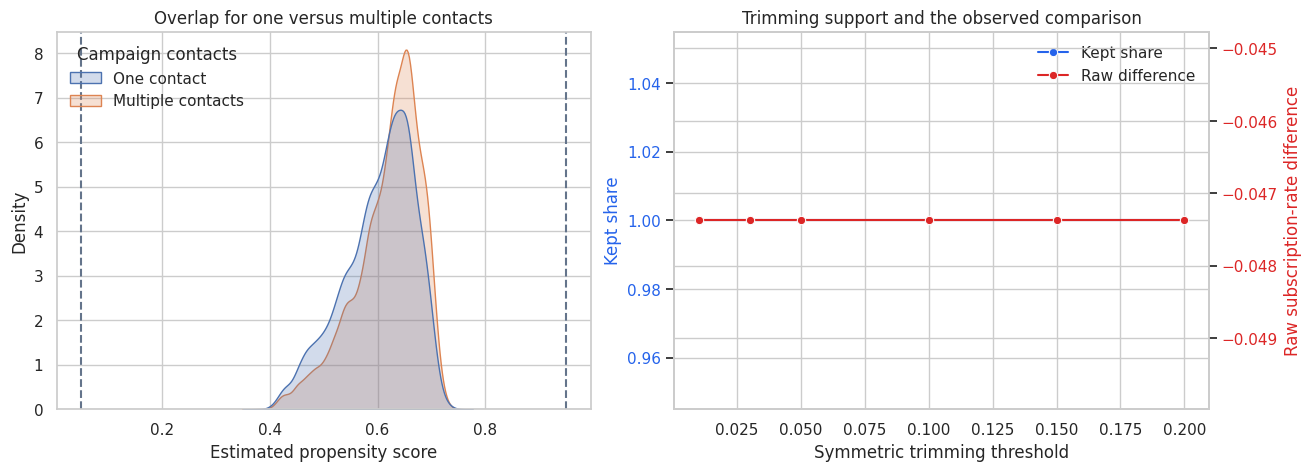

In [22]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_uci_bank_marketing, optional_data_note

RUN_REAL_DATA_COMPANION = True
BANK_MARKETING_SOURCE = "https://archive.ics.uci.edu/dataset/222/bank+marketing"

if RUN_REAL_DATA_COMPANION:
    bank = load_uci_bank_marketing().copy()
    bank["subscribed"] = (bank["y"] == "yes").astype(int)
    bank["multiple_contacts"] = (bank["campaign"] > 1).astype(int)
    bank["contact_group"] = bank["multiple_contacts"].map({0: "One contact", 1: "Multiple contacts"})
    bank["has_previous_contact"] = (bank["previous"] > 0).astype(int)
    bank["pdays_observed"] = (bank["pdays"] >= 0).astype(int)
    bank["log_balance"] = np.sign(bank["balance"]) * np.log1p(np.abs(bank["balance"]))
    bank["contact_count_capped"] = bank["campaign"].clip(upper=8)
    baseline_covariates = ["age", "log_balance", "has_previous_contact", "pdays_observed"]

    from sklearn.compose import ColumnTransformer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    numeric_features = ["age", "log_balance", "has_previous_contact", "pdays_observed"]
    categorical_features = ["job", "marital", "education", "housing", "loan"]
    model_features = numeric_features + categorical_features

    propensity_pipeline = make_pipeline(
        ColumnTransformer(
            [
                ("numeric", StandardScaler(), numeric_features),
                ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ]
        ),
        LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs"),
    )
    propensity_pipeline.fit(bank[model_features], bank["multiple_contacts"])
    bank["ps"] = propensity_pipeline.predict_proba(bank[model_features])[:, 1].clip(0.001, 0.999)

    trimming_rows = []
    for alpha in [0.01, 0.03, 0.05, 0.10, 0.15, 0.20]:
        keep = bank["ps"].between(alpha, 1 - alpha)
        kept = bank.loc[keep]
        if kept.empty or kept["multiple_contacts"].nunique() < 2:
            continue
        diff = (
            kept.loc[kept["multiple_contacts"] == 1, "subscribed"].mean()
            - kept.loc[kept["multiple_contacts"] == 0, "subscribed"].mean()
        )
        trimming_rows.append(
            {
                "alpha": alpha,
                "kept_share": keep.mean(),
                "kept_customers": int(keep.sum()),
                "one_contact_share_kept": np.mean(keep & (bank["multiple_contacts"] == 0)) / np.mean(bank["multiple_contacts"] == 0),
                "multiple_contact_share_kept": np.mean(keep & (bank["multiple_contacts"] == 1)) / np.mean(bank["multiple_contacts"] == 1),
                "raw_difference_inside_trimmed_sample": diff,
            }
        )

    trimming_table = pd.DataFrame(trimming_rows)
    smart_display(trimming_table.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6), constrained_layout=True)
    sns.kdeplot(
        data=bank,
        x="ps",
        hue="contact_group",
        hue_order=["One contact", "Multiple contacts"],
        common_norm=False,
        fill=True,
        alpha=0.25,
        ax=axes[0],
    )
    axes[0].axvline(0.05, color="#64748b", linestyle="--", linewidth=1.5, label="0.05 trim")
    axes[0].axvline(0.95, color="#64748b", linestyle="--", linewidth=1.5)
    axes[0].set_title("Overlap for one versus multiple contacts")
    axes[0].set_xlabel("Estimated propensity score")
    axes[0].set_ylabel("Density")
    legend = axes[0].get_legend()
    if legend is not None:
        legend.set_title("Campaign contacts")
        legend.set_frame_on(False)

    sns.lineplot(
        data=trimming_table,
        x="alpha",
        y="kept_share",
        marker="o",
        color="#2563eb",
        ax=axes[1],
        label="Kept share",
    )
    axes[1].set_title("Trimming support and the observed comparison")
    axes[1].set_xlabel("Symmetric trimming threshold")
    axes[1].set_ylabel("Kept share", color="#2563eb")
    axes[1].tick_params(axis="y", labelcolor="#2563eb")

    comparison_axis = axes[1].twinx()
    sns.lineplot(
        data=trimming_table,
        x="alpha",
        y="raw_difference_inside_trimmed_sample",
        marker="o",
        color="#dc2626",
        ax=comparison_axis,
        label="Raw difference",
    )
    comparison_axis.set_ylabel("Raw subscription-rate difference", color="#dc2626")
    comparison_axis.tick_params(axis="y", labelcolor="#dc2626")

    handles, labels = axes[1].get_legend_handles_labels()
    twin_handles, twin_labels = comparison_axis.get_legend_handles_labels()
    axes[1].legend(handles + twin_handles, labels + twin_labels, frameon=False, loc="best")
    comparison_axis.get_legend().remove()
    plt.show()
else:
    optional_data_note("UCI Bank Marketing", BANK_MARKETING_SOURCE, "RUN_REAL_DATA_COMPANION")

The real-data companion shows that trimming is also an estimand decision. As the threshold changes, the analysis population changes too. A more stable comparison may become possible, but the estimand moves toward customers who could plausibly have had either exposure level.

That is the right way to explain trimming in a stakeholder report: it is a choice about support and target population, not a magic fix for observational bias.

## References

Crump, R. K., Hotz, V. J., Imbens, G. W., & Mitnik, O. A. (2009). Dealing with limited overlap in estimation of average treatment effects. *Biometrika, 96*(1), 187-199. https://doi.org/10.1093/biomet/asn055

Li, F., Morgan, K. L., & Zaslavsky, A. M. (2017). Balancing covariates via propensity score weighting. *Journal of the American Statistical Association, 113*(521), 390-400. https://doi.org/10.1080/01621459.2016.1260466

Petersen, M. L., Porter, K. E., Gruber, S., Wang, Y., & van der Laan, M. J. (2010). Diagnosing and responding to violations in the positivity assumption. *Statistical Methods in Medical Research, 21*(1), 31-54. https://doi.org/10.1177/0962280210386207

Westreich, D., & Cole, S. R. (2010). Invited commentary: Positivity in practice. *American Journal of Epidemiology, 171*(6), 674-677. https://doi.org/10.1093/aje/kwp436

Yang, S., & Ding, P. (2018). Asymptotic inference of causal effects with observational studies trimmed by the estimated propensity scores. *Biometrika, 105*(2), 487-493. https://doi.org/10.1093/biomet/asy008